In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family="Malgun Gothic")
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# train.csv 파일 로드(ID제외)
train = pd.read_csv('Data/train.csv').drop(columns=['ID'])

# 1. 데이터 구조 및 유형 확인

# 데이터 형태 확인
print("데이터 형태:", train.shape)

# 변수 종류 확인
print("변수 종류:")
print(train.dtypes)

데이터 형태: (256351, 68)
변수 종류:
시술 시기 코드                  object
시술 당시 나이                  object
임신 시도 또는 마지막 임신 경과 연수    float64
시술 유형                     object
특정 시술 유형                  object
                          ...   
난자 해동 경과일                float64
난자 혼합 경과일                float64
배아 이식 경과일                float64
배아 해동 경과일                float64
임신 성공 여부                   int64
Length: 68, dtype: object


결측치:


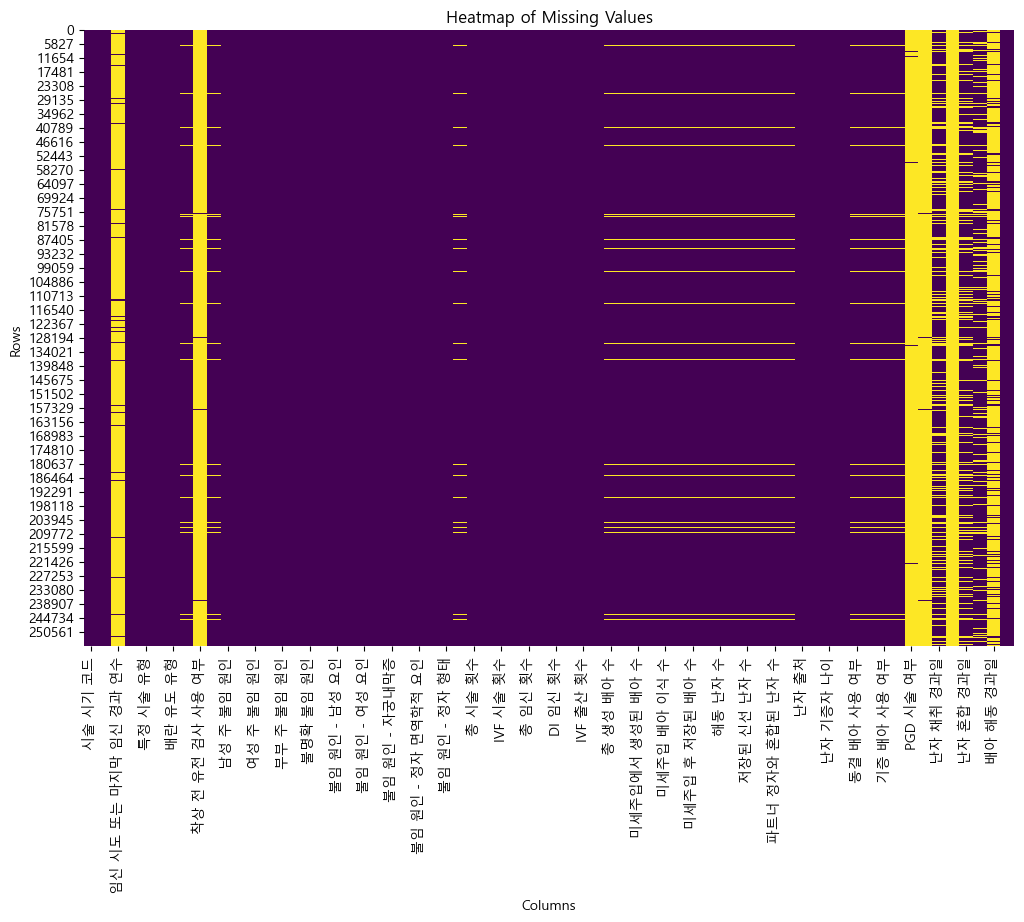

In [3]:
# 결측치 시각화
print("결측치:")
plt.figure(figsize=(12, 8))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

기술 통계:
       임신 시도 또는 마지막 임신 경과 연수       배란 자극 여부    단일 배아 이식 여부  착상 전 유전 검사 사용 여부  \
count            9370.000000  256351.000000  250060.000000            2718.0   
mean                9.270651       0.771286       0.233476               1.0   
std                 3.550313       0.420005       0.423043               0.0   
min                 0.000000       0.000000       0.000000               1.0   
25%                 7.000000       1.000000       0.000000               1.0   
50%                 9.000000       1.000000       0.000000               1.0   
75%                11.000000       1.000000       0.000000               1.0   
max                20.000000       1.000000       1.000000               1.0   

       착상 전 유전 진단 사용 여부     남성 주 불임 원인     남성 부 불임 원인     여성 주 불임 원인  \
count     250060.000000  256351.000000  256351.000000  256351.000000   
mean           0.012781       0.028516       0.013115       0.030724   
std            0.112328       0.166441       0.113767   

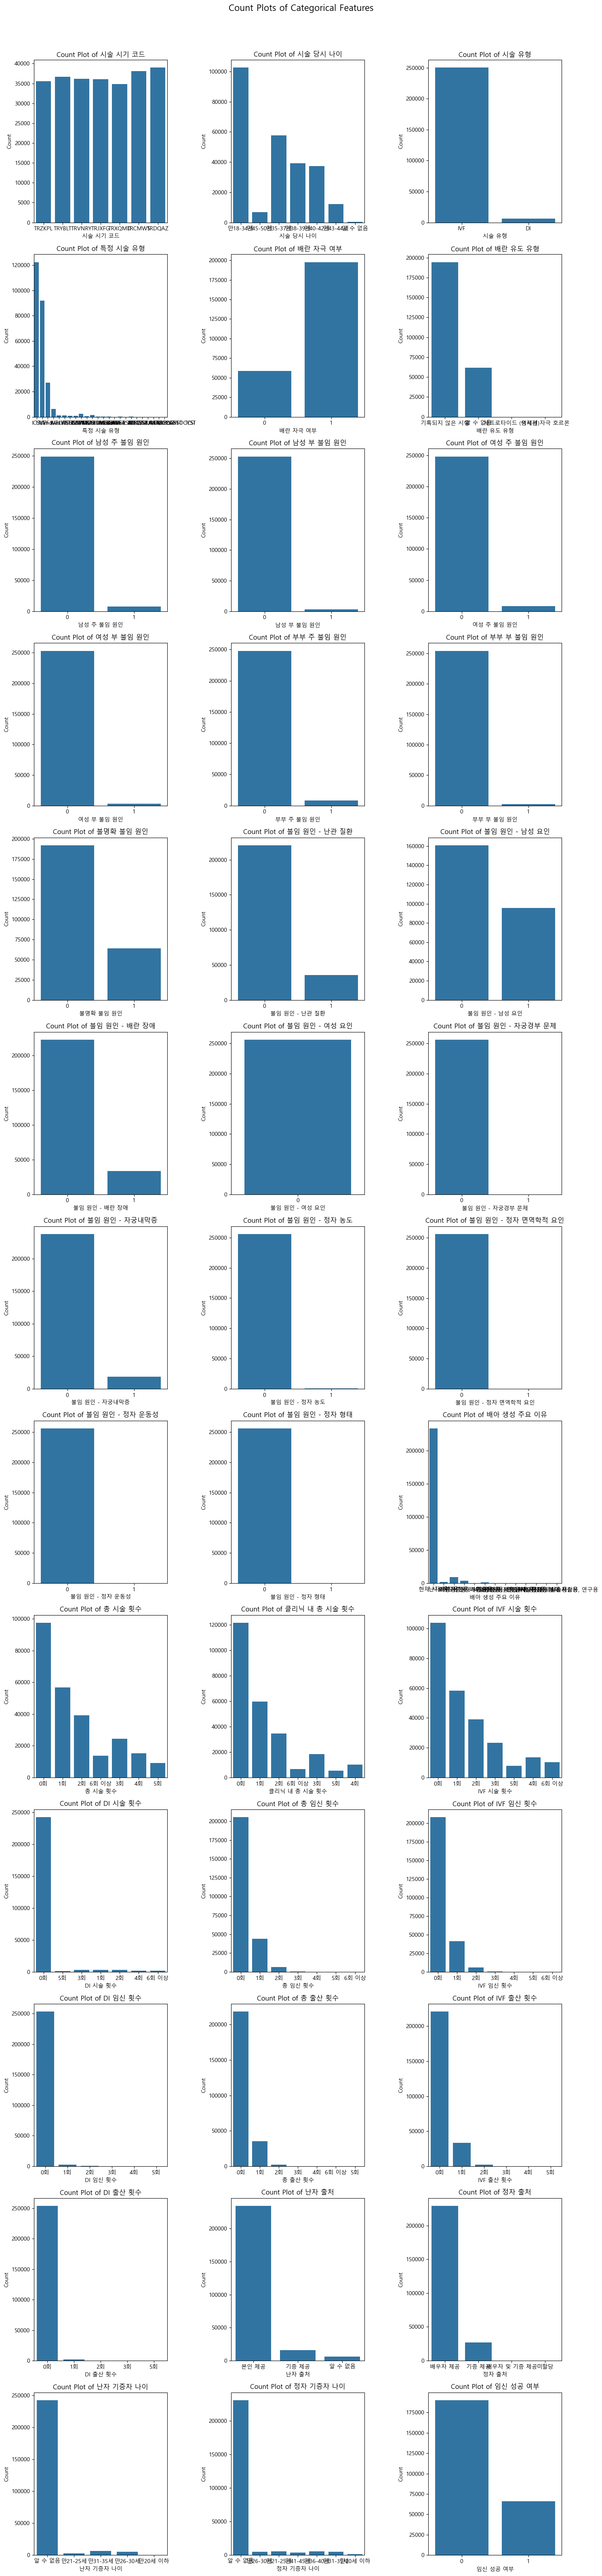

In [4]:
import math
# 2. 데이터 통계 및 시각화

# 기술 통계 확인
print("기술 통계:")
print(train.describe())

categorical_cols = train.select_dtypes(include=['object', 'int64']).columns
numerical_cols = train.select_dtypes(include=['float64']).columns

num_cols = len(categorical_cols)
num_rows = math.ceil(num_cols / 3)  # 예시: 3열로 배치, 필요에 따라 조정

# 전체 Figure 및 Subplots 생성
fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5 * num_rows)) # figsize 조정

# 전체 Figure 제목 (옵션)
fig.suptitle('Count Plots of Categorical Features', fontsize=16)

# 각 subplot에 countplot 그리기
for i, col in enumerate(categorical_cols):
    ax = axes[i // 3, i % 3]  # 행, 열 인덱스 계산
    sns.countplot(data=train, x=col, ax=ax) # ax 파라미터에 subplot 지정
    ax.set_title(f'Count Plot of {col}') # subplot 제목 설정 (옵션)
    ax.tick_params(axis='x', labelsize=10) # x축 레이블 설정 (옵션)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

# 빈 subplot 제거 및 레이아웃 조정
if num_cols < num_rows * 3: # subplot이 부족한 경우 빈 subplot 제거
    for j in range(num_cols, num_rows * 3):
        fig.delaxes(axes.flatten()[j]) # 빈 subplot 삭제

plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
plt.show()


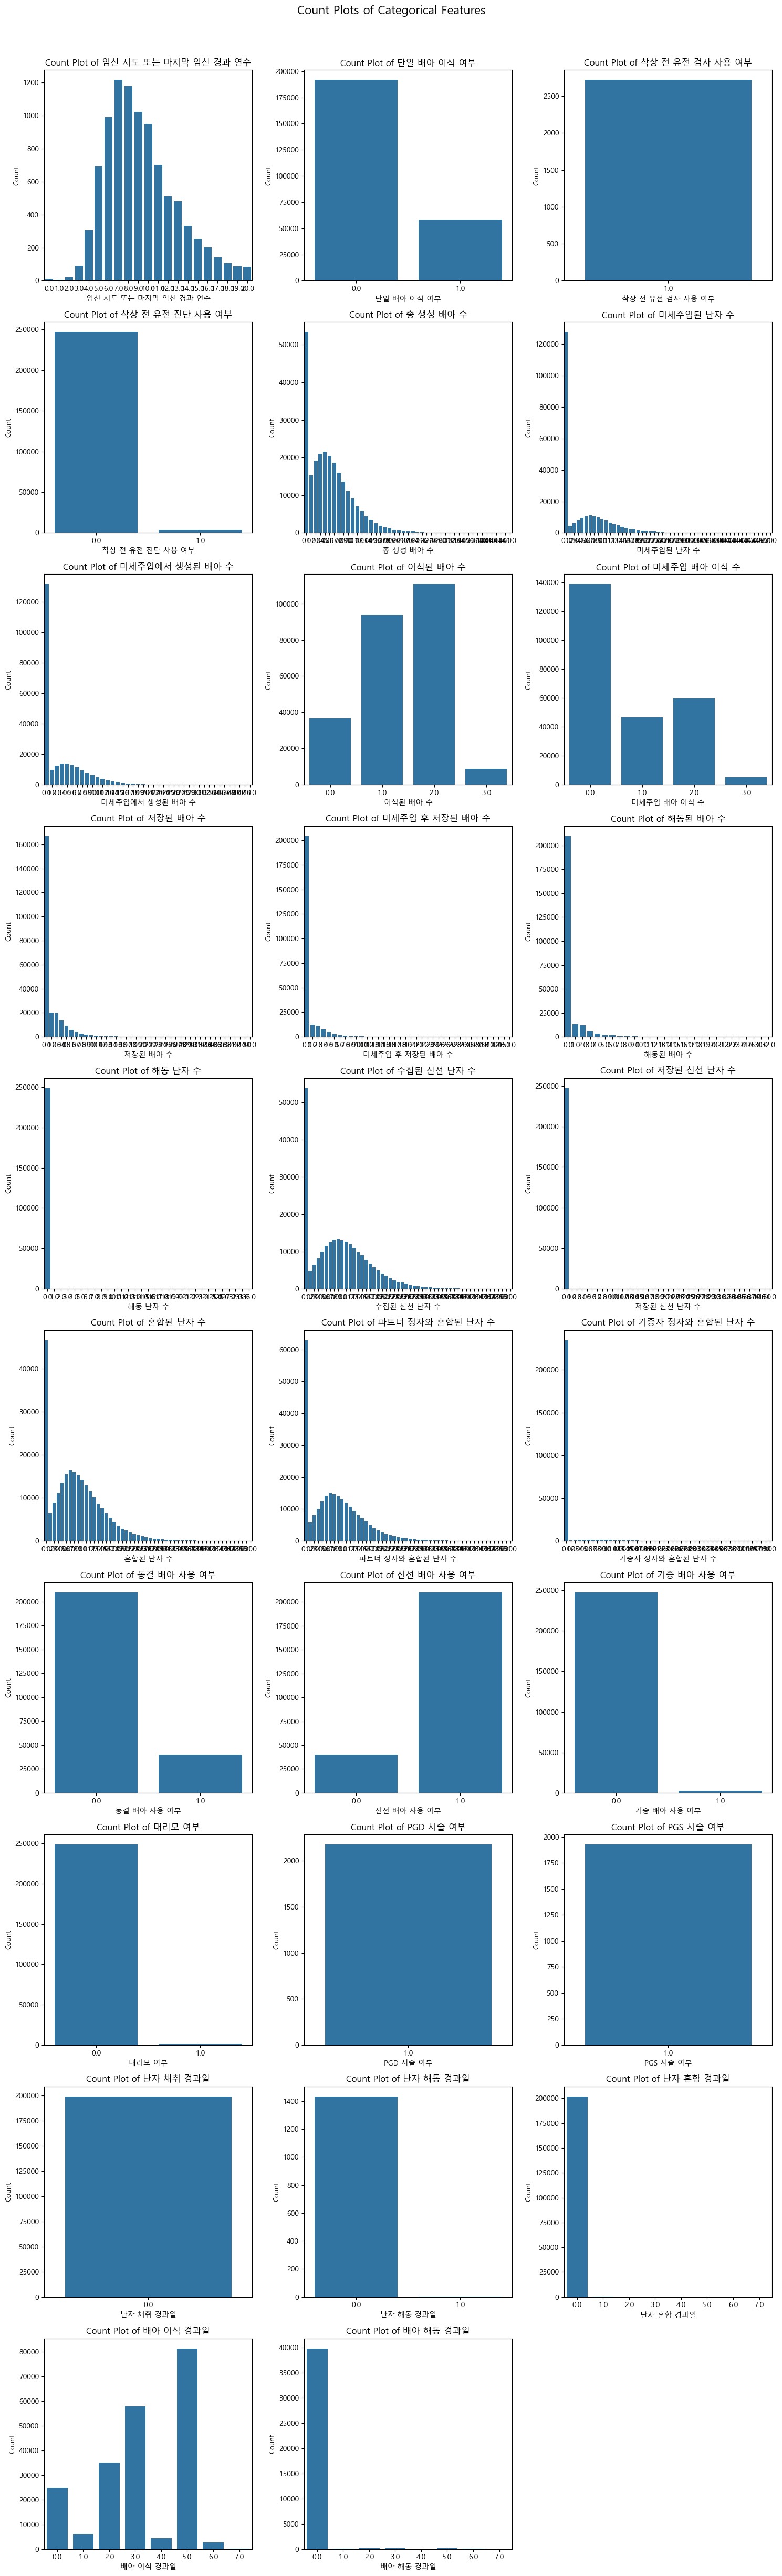

In [7]:
num_cols = len(numerical_cols)
num_rows = math.ceil(num_cols / 3)  # 예시: 3열로 배치, 필요에 따라 조정

# 전체 Figure 및 Subplots 생성
fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5 * num_rows)) # figsize 조정

# 전체 Figure 제목 (옵션)
fig.suptitle('Count Plots of Categorical Features', fontsize=16)

# 각 subplot에 countplot 그리기
for i, col in enumerate(numerical_cols):
    ax = axes[i // 3, i % 3]  # 행, 열 인덱스 계산
    sns.countplot(data=train, x=col, ax=ax) # ax 파라미터에 subplot 지정
    ax.set_title(f'Count Plot of {col}') # subplot 제목 설정 (옵션)
    ax.tick_params(axis='x', labelsize=10) # x축 레이블 설정 (옵션)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

# 빈 subplot 제거 및 레이아웃 조정
if num_cols < num_rows * 3: # subplot이 부족한 경우 빈 subplot 제거
    for j in range(num_cols, num_rows * 3):
        fig.delaxes(axes.flatten()[j]) # 빈 subplot 삭제

plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
plt.show()
